<a href="https://colab.research.google.com/github/carolynee01/receding-hairline/blob/main/receding_hairline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Konfiguracja i reprodukowalność

In [27]:
import random
import numpy as np
import tensorflow as tf

# Ustalenie ziarna losowości
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Ustalono seed losowości na wartość: {SEED}")

Ustalono seed losowości na wartość: 42


In [28]:
import os
import cv2
import matplotlib.pyplot as plt

if not os.path.exists('data'):
    os.makedirs('data/zakola')
    os.makedirs('data/brak_zakoli')

print("Środowisko przygotowane.")

Środowisko przygotowane.


Pobranie danych


In [29]:
import kagglehub

# Pobieranie zbioru
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Zbiór pobrano do:", path)

# Ustawienie ścieżek na podstawie pobranej lokalizacji
# Zazwyczaj struktura w tym dataset to:
img_folder = os.path.join(path, "img_align_celeba/img_align_celeba")
attr_csv_path = os.path.join(path, "list_attr_celeba.csv")

# Teraz możesz wczytać CSV używając nowej ścieżki
import pandas as pd
attr_df = pd.read_csv(attr_csv_path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Zbiór pobrano do: /kaggle/input/celeba-dataset


Podział i selekcja zdjęć ze zbioru

In [30]:
import shutil

# Wczytanie pliku CSV
attr_df = pd.read_csv('/kaggle/input/celeba-dataset/list_attr_celeba.csv')

# Wybranie zdjęć z zakolami (Receding_Hairline = 1)
zakola_list = attr_df[attr_df['Receding_Hairline'] == 1]['image_id'].head(5000).tolist()

# Wybranie zdjęć bez zakoli (Receding_Hairline = -1)
brak_zakoli_list = attr_df[attr_df['Receding_Hairline'] == -1]['image_id'].head(5000).tolist()

print(f"Wyselekcjonowano {len(zakola_list)} zdjęć z zakolami i {len(brak_zakoli_list)} bez zakoli.")

Wyselekcjonowano 5000 zdjęć z zakolami i 5000 bez zakoli.


Podstawowa funkcja preprocessingu

In [31]:
# Poprawienie ścieżki do zdjęć
# kagglehub pobiera dane do specyficznego folderu, musimy do niego wejść głębiej
img_folder_path = os.path.join(path, "img_align_celeba", "img_align_celeba")

def preprocess_image(img_id, size=(128, 128)):
    # Tworzymy pełną ścieżkę do konkretnego pliku
    full_path = os.path.join(img_folder_path, img_id)
    img = cv2.imread(full_path)

    if img is None:
        print(f"Nie udało się wczytać: {full_path}")
        return None

    # Transformacja geometryczna - Skalowanie (Dyskretyzacja/Próbkowanie)
    img_resized = cv2.resize(img, size)

    # Konwersja między przestrzeniami barw (RGB na Skalę szarości)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    return gray

Akwizycja oraz dyskretyzacja obrazów

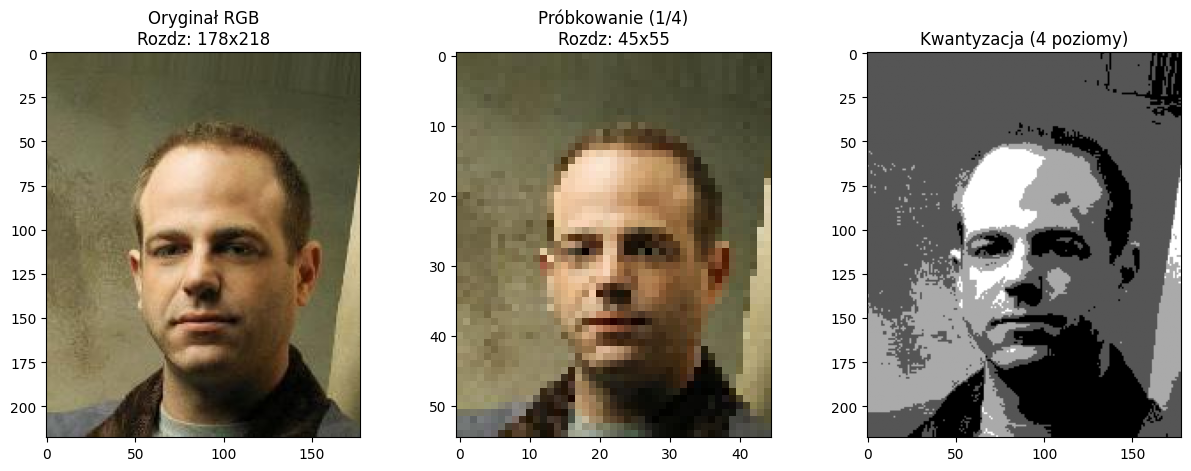

In [32]:
# Wczytanie obrazu
path_to_sample = os.path.join(img_folder_path, zakola_list[0])
img_bgr = cv2.imread(path_to_sample)

if img_bgr is not None:
    # Konwersja między przestrzeniami barw
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Dyskretyzacja: próbkowanie (zmniejszenie rozdzielczości)
    # Próbkowanie co 4 piksel (downsampling)
    sampling_factor = 4
    img_sampled = img_rgb[::sampling_factor, ::sampling_factor]

    # Dyskretyzacja: Kwantyzacja (zmniejszenie liczby poziomów jasności)
    # Redukcja do 4 poziomów (2 bity) zamiast 256 (8 bitów)
    levels = 4
    img_quantized = np.floor_divide(img_gray, 256//levels) * (256//levels)

    # Wizualizacja i opis parametrów
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title(f"Oryginał RGB\nRozdz: {img_rgb.shape[1]}x{img_rgb.shape[0]}")

    plt.subplot(1, 3, 2)
    plt.imshow(img_sampled)
    plt.title(f"Próbkowanie (1/{sampling_factor})\nRozdz: {img_sampled.shape[1]}x{img_sampled.shape[0]}")

    plt.subplot(1, 3, 3)
    plt.imshow(img_quantized, cmap='gray')
    plt.title(f"Kwantyzacja ({levels} poziomy)")

    plt.show()
else:
    print("Błąd: Nie znaleziono pliku obrazu.")

Histogram intensywności przed i po dyskretyzacji

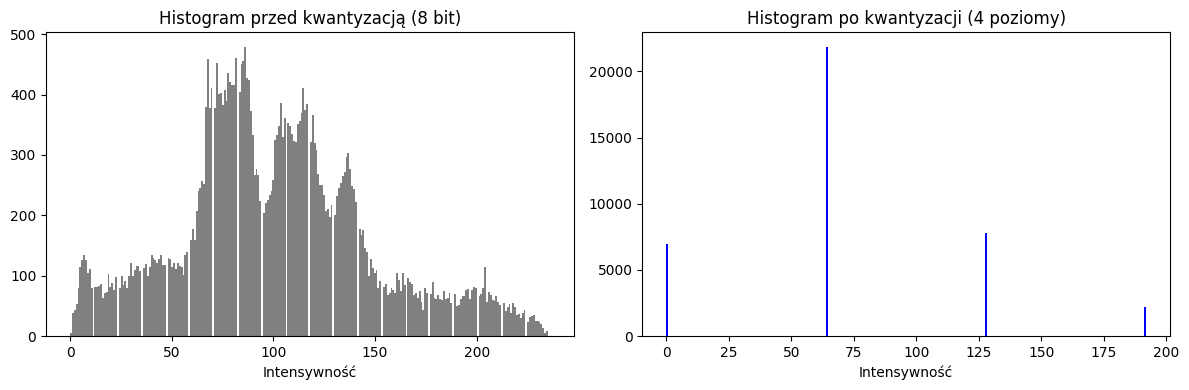

In [33]:
def plot_histograms(before, after):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(before.ravel(), bins=256, color='gray')
    plt.title("Histogram przed kwantyzacją (8 bit)")
    plt.xlabel("Intensywność")

    plt.subplot(1, 2, 2)
    plt.hist(after.ravel(), bins=256, color='blue')
    plt.title(f"Histogram po kwantyzacji ({levels} poziomy)")
    plt.xlabel("Intensywność")

    plt.tight_layout()
    plt.show()

if img_bgr is not None:
    plot_histograms(img_gray, img_quantized)

Podstawowe algorytmy obróbki obrazów

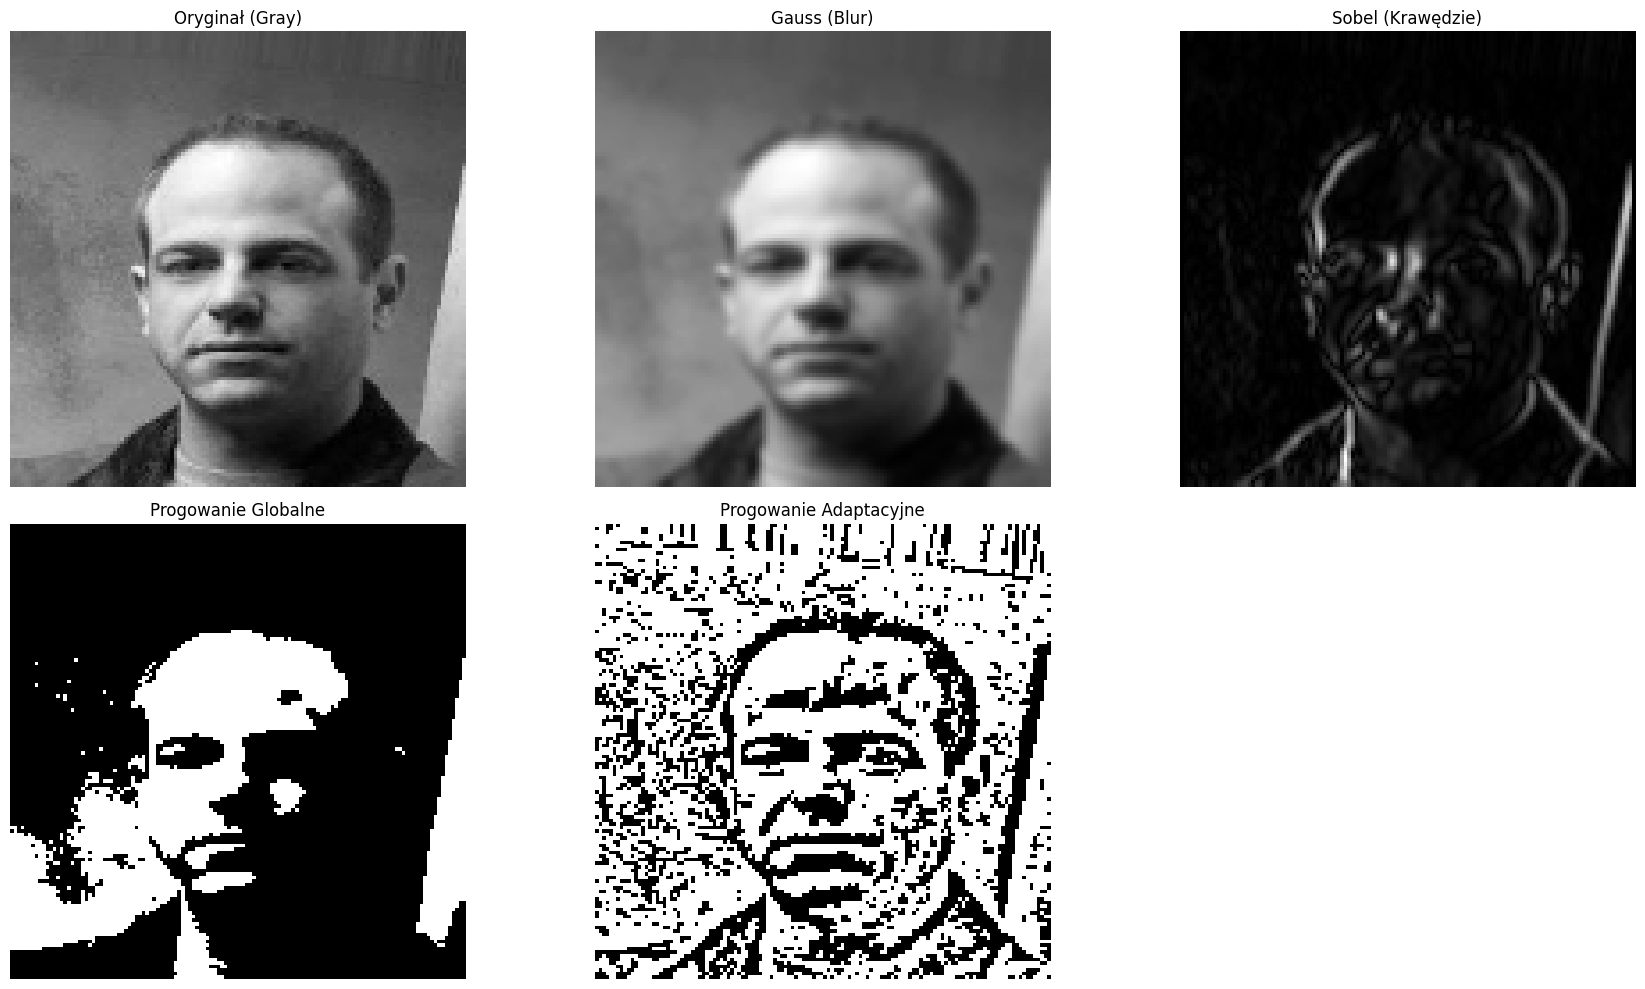

In [34]:
sample_img = preprocess_image(zakola_list[0])

if sample_img is not None:
    # Implementacja i porównanie filtrów (wymagane co najmniej trzy)
    blur = cv2.GaussianBlur(sample_img, (5, 5), 0)            # 1. Filtr Gaussa
    edges_sobel = cv2.Sobel(sample_img, cv2.CV_64F, 1, 0, ksize=5)  # 2. Filtr Sobela
    median = cv2.medianBlur(sample_img, 5)                   # 3. Filtr medianowy

    # Progowanie (Thresholding) - Globalne vs Adaptacyjne
    _, thresh_global = cv2.threshold(sample_img, 127, 255, cv2.THRESH_BINARY)
    thresh_adapt = cv2.adaptiveThreshold(sample_img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)

    # Wizualizacja wyników
    titles = ['Oryginał (Gray)', 'Gauss (Blur)', 'Sobel (Krawędzie)',
              'Progowanie Globalne', 'Progowanie Adaptacyjne']
    images = [sample_img, blur, edges_sobel, thresh_global, thresh_adapt]

    plt.figure(figsize=(18, 10))
    for i in range(len(images)):
        plt.subplot(2, 3, i+1)
        display_img = images[i]
        if titles[i] == 'Sobel (Krawędzie)':
            display_img = np.absolute(display_img)

        plt.imshow(display_img, cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

 Pomiary parametrów obiektów na obrazach

--- TABELA WYNIKÓW ---
           ID   Klasa     Pole    Obwod  Wys_BBox
0  000025.jpg  Zakola  11478.0   580.82       169
1  000031.jpg  Zakola  14375.5   806.80       197
2  000049.jpg  Zakola  15939.5   539.32       175
3  000051.jpg  Zakola  13365.0   497.30       167
4  000081.jpg  Zakola  12613.0   508.82       165
5  000001.jpg    Brak  31674.0  1181.16       218
6  000002.jpg    Brak  19919.0   912.27       218
7  000003.jpg    Brak  16157.0   776.48       201
8  000004.jpg    Brak  16447.5   858.66       218
9  000005.jpg    Brak  16042.5   716.60       207


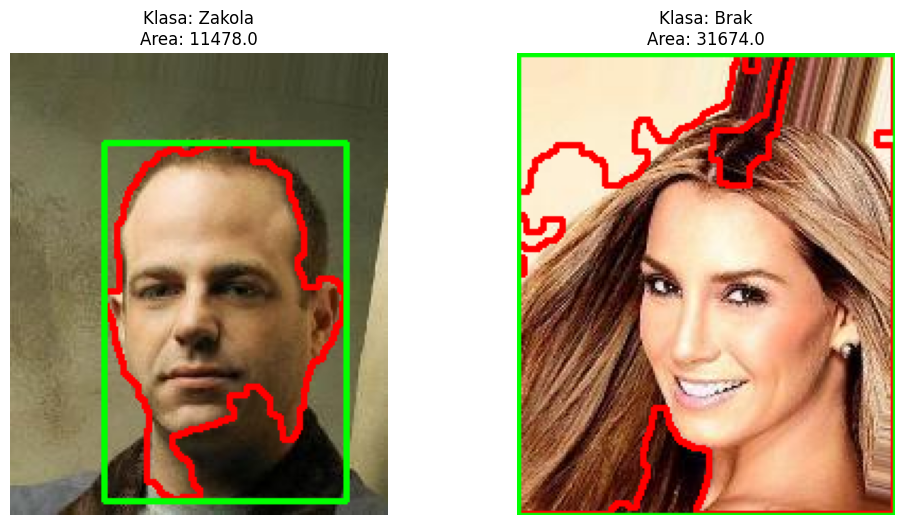

In [35]:
# Lista na wyniki do tabeli
l3_results = []

def measure_forehead(img_id, label_name):
    full_path = os.path.join(img_folder_path, img_id)
    img_bgr = cv2.imread(full_path)
    if img_bgr is None: return None, None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Redukcja szumów przed segmentacją
    blurred = cv2.GaussianBlur(img_bgr, (7, 7), 0)

    # Konwersja do HSV dla lepszej maski skóry
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    # Definiujemy zakres koloru skóry w HSV
    lower_skin = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin = np.array([20, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower_skin, upper_skin)

    # Operacje morfologiczne - czyszczenie maski
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel) # Usuwa małe kropki
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # Łączy dziury

    # 4. Detekcja konturów na poprawionej masce
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Szukamy konturu, który jest najwyżej (linia włosów jest u góry)
        # i ma odpowiednią wielkość
        valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 2000]
        if not valid_contours: return None, None

        c = max(valid_contours, key=cv2.contourArea)

        area = cv2.contourArea(c)
        perimeter = cv2.arcLength(c, True)
        x, y, w, h = cv2.boundingRect(c)

        return {
            'ID': img_id, 'Klasa': label_name, 'Pole': round(area, 2),
            'Obwod': round(perimeter, 2), 'Wys_BBox': h
        }, (img_rgb, c, (x, y, w, h))
    return None, None

# Analiza 10 obiektów (5 z zakolami, 5 bez)
test_samples = zakola_list[:5] + brak_zakoli_list[:5]
display_images = []

for i, img_id in enumerate(test_samples):
    label = "Zakola" if i < 5 else "Brak"
    res, visual_data = measure_forehead(img_id, label)
    if res:
        l3_results.append(res)
        if i in [0, 5]: # Zapamiętujemy po jednym przykładzie do wizualizacji
            display_images.append((visual_data, label))

# Tworzenie tabeli (wymagane w dokumentacji)
df_l3 = pd.DataFrame(l3_results)
print("--- TABELA WYNIKÓW ---")
print(df_l3)

# Wizualizacja
plt.figure(figsize=(12, 6))
for i, ((img, cnt, bbox), label) in enumerate(display_images):
    plt.subplot(1, 2, i+1)
    x, y, w, h = bbox
    # Rysujemy kontur i bounding box na obrazie
    cv2.drawContours(img, [cnt], -1, (255, 0, 0), 2)
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    plt.imshow(img)
    plt.title(f"Klasa: {label}\nArea: {cv2.contourArea(cnt)}")
    plt.axis('off')
plt.show()

Ekstrakcja cech na obrazach

Przetwarzanie klasy 1...
Przetwarzanie klasy 0...


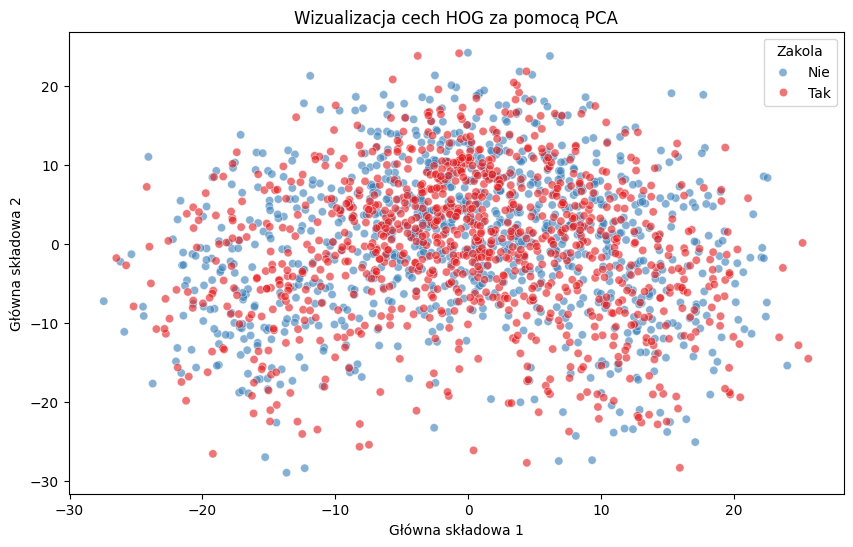


--- WYNIKI ---
Skuteczność SVM na cechach HOG: 66.75%
Skuteczność k-NN na cechach HOG: 67.75%


In [36]:
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Funkcja ekstrakcji cech HOG
def get_hog_dataset(image_ids, label):
    features_list = []
    labels_list = []
    print(f"Przetwarzanie klasy {label}...")
    for img_id in image_ids:
        # Używamy Twojej funkcji preprocess_image (Gray + Resize 128x128)
        img = preprocess_image(img_id)
        if img is not None:
            # orientations=9, pixels_per_cell=(16,16) - parametry dla twarzy
            fd = hog(img, orientations=9, pixels_per_cell=(16, 16),
                     cells_per_block=(2, 2), visualize=False)
            features_list.append(fd)
            labels_list.append(label)
    return features_list, labels_list

# Ekstrakcja dla zbalansowanego zbioru (np. po 1000 na klasę dla szybkości)
X_z, y_z = get_hog_dataset(zakola_list[:1000], 1)
X_b, y_b = get_hog_dataset(brak_zakoli_list[:1000], 0)

X = np.array(X_z + X_b)
y = np.array(y_z + y_b)

# Standaryzacja danych przed PCA
X_scaled = StandardScaler().fit_transform(X)

# 2. Redukcja wymiarowości PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Wizualizacja skupisk
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.6)
plt.title("Wizualizacja cech HOG za pomocą PCA")
plt.xlabel("Główna składowa 1")
plt.ylabel("Główna składowa 2")
plt.legend(title='Zakola', labels=['Nie', 'Tak'])
plt.show()

# 3. Porównanie klasyfikatorów
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)

# Testujemy SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
acc_svm = accuracy_score(y_test, svm.predict(X_test))

# Testujemy k-NN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test))

print(f"\n--- WYNIKI ---")
print(f"Skuteczność SVM na cechach HOG: {acc_svm*100:.2f}%")
print(f"Skuteczność k-NN na cechach HOG: {acc_knn*100:.2f}%")

Implementacja konwolucyjnej sieci neuronowej

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# Przygotowanie DataFrame do generatora
df_all = pd.DataFrame({
    'filename': zakola_list + brak_zakoli_list,
    'label': ['1'] * len(zakola_list) + ['0'] * len(brak_zakoli_list)
})

# Podział na zbiory: 70% trening, 15% walidacja, 15% test
train_df, test_df = train_test_split(df_all, test_size=0.3, random_state=SEED, stratify=df_all['label'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=SEED, stratify=test_df['label'])

# Konfiguracja augmentacji
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # Obroty
    width_shift_range=0.1,  # Przesunięcia
    height_shift_range=0.1,
    horizontal_flip=True,   # Odbicia
    brightness_range=[0.8, 1.2] # Zmiana jasności
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Tworzenie generatorów
train_gen = train_datagen.flow_from_dataframe(
    train_df, directory=img_folder_path, x_col='filename', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, directory=img_folder_path, x_col='filename', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', seed=SEED
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, directory=img_folder_path, x_col='filename', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False, seed=SEED
)

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.


In [38]:
'''
# Budowa modelu CNN

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(1, activation='sigmoid') # Klasyfikacja binarna
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Trening modelu
print("\n--- Rozpoczynam trening sieci CNN ---")
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen
)
# Zapisywanie historii treningu
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('/content/drive/MyDrive/training_history.csv', index=False)
'''

'\n# Budowa modelu CNN\n\nmodel = models.Sequential([\n    layers.Input(shape=(128, 128, 3)),\n    layers.Conv2D(32, (3, 3), activation=\'relu\'),\n    layers.MaxPooling2D(2, 2),\n    layers.Conv2D(64, (3, 3), activation=\'relu\'),\n    layers.MaxPooling2D(2, 2),\n    layers.Conv2D(128, (3, 3), activation=\'relu\'),\n    layers.MaxPooling2D(2, 2),\n    layers.Flatten(),\n    layers.Dense(128, activation=\'relu\'),\n    layers.Dropout(0.5), # Zapobiega przeuczeniu\n    layers.Dense(1, activation=\'sigmoid\') # Klasyfikacja binarna\n])\n\nmodel.compile(optimizer=\'adam\', loss=\'binary_crossentropy\', metrics=[\'accuracy\'])\n\n# Trening modelu\nprint("\n--- Rozpoczynam trening sieci CNN ---")\nhistory = model.fit(\n    train_gen,\n    epochs=15,\n    validation_data=val_gen\n)\n# Zapisywanie historii treningu\nhist_df = pd.DataFrame(history.history)\nhist_df.to_csv(\'/content/drive/MyDrive/training_history.csv\', index=False)\n'

In [39]:
# Zapisanie całego modelu (architektura + wagi + konfiguracja optimizera)
#model_path = '/content/drive/MyDrive/zakola_model.keras'
#model.save(model_path)
#print(f"Model został zapisany na Dysku Google: {model_path}")

In [40]:
from tensorflow.keras.models import load_model

# Wczytanie modelu
model_path = '/content/drive/MyDrive/zakola_model.keras'
model = load_model(model_path)
print("Model wczytany pomyślnie!")

Model wczytany pomyślnie!


In [41]:
# Wczytanie historii treningu
history_data = pd.read_csv('/content/drive/MyDrive/training_history.csv')

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step

--- RAPORT KLASYFIKACJI (CNN) ---
              precision    recall  f1-score   support

        Brak       0.79      0.86      0.83       750
      Zakola       0.85      0.77      0.81       750

    accuracy                           0.82      1500
   macro avg       0.82      0.82      0.82      1500
weighted avg       0.82      0.82      0.82      1500



<Figure size 800x600 with 0 Axes>

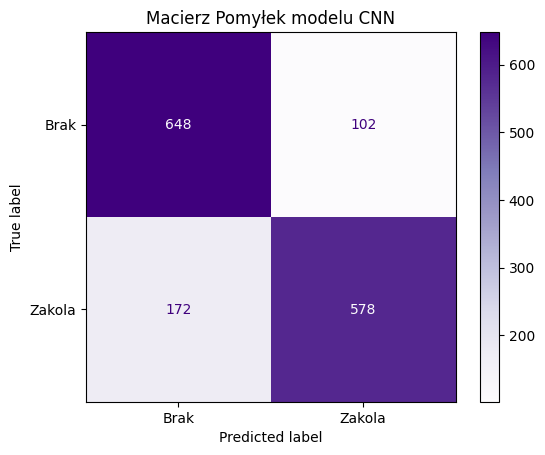

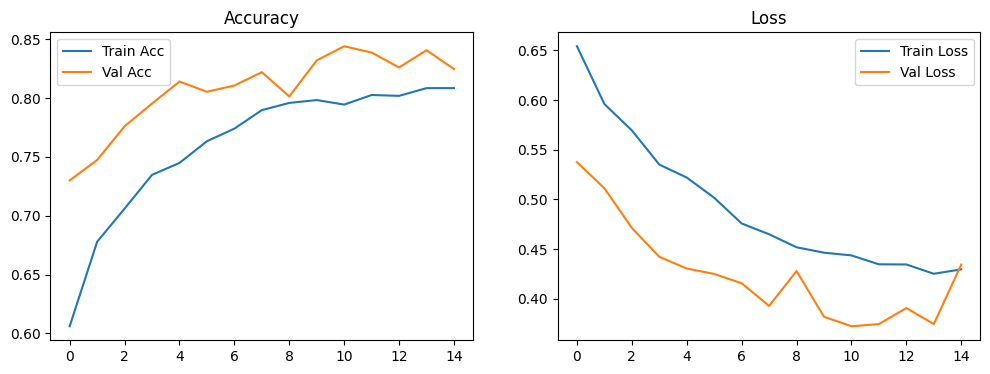

In [42]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predykcja na zbiorze testowym
test_gen.reset()
preds = (model.predict(test_gen) > 0.5).astype(int)
y_true = test_gen.classes

# Wyświetlenie metryk
print("\n--- RAPORT KLASYFIKACJI (CNN) ---")
print(classification_report(y_true, preds, target_names=['Brak', 'Zakola']))

# Wizualizacja macierzy pomyłek
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_true, preds, display_labels=['Brak', 'Zakola'], cmap='Purples')
plt.title("Macierz Pomyłek modelu CNN")
plt.show()

# Wykresy krzywych uczenia
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_data['accuracy'], label='Train Acc')
plt.plot(history_data['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_data['loss'], label='Train Loss')
plt.plot(history_data['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

Przykłady ze zbioru

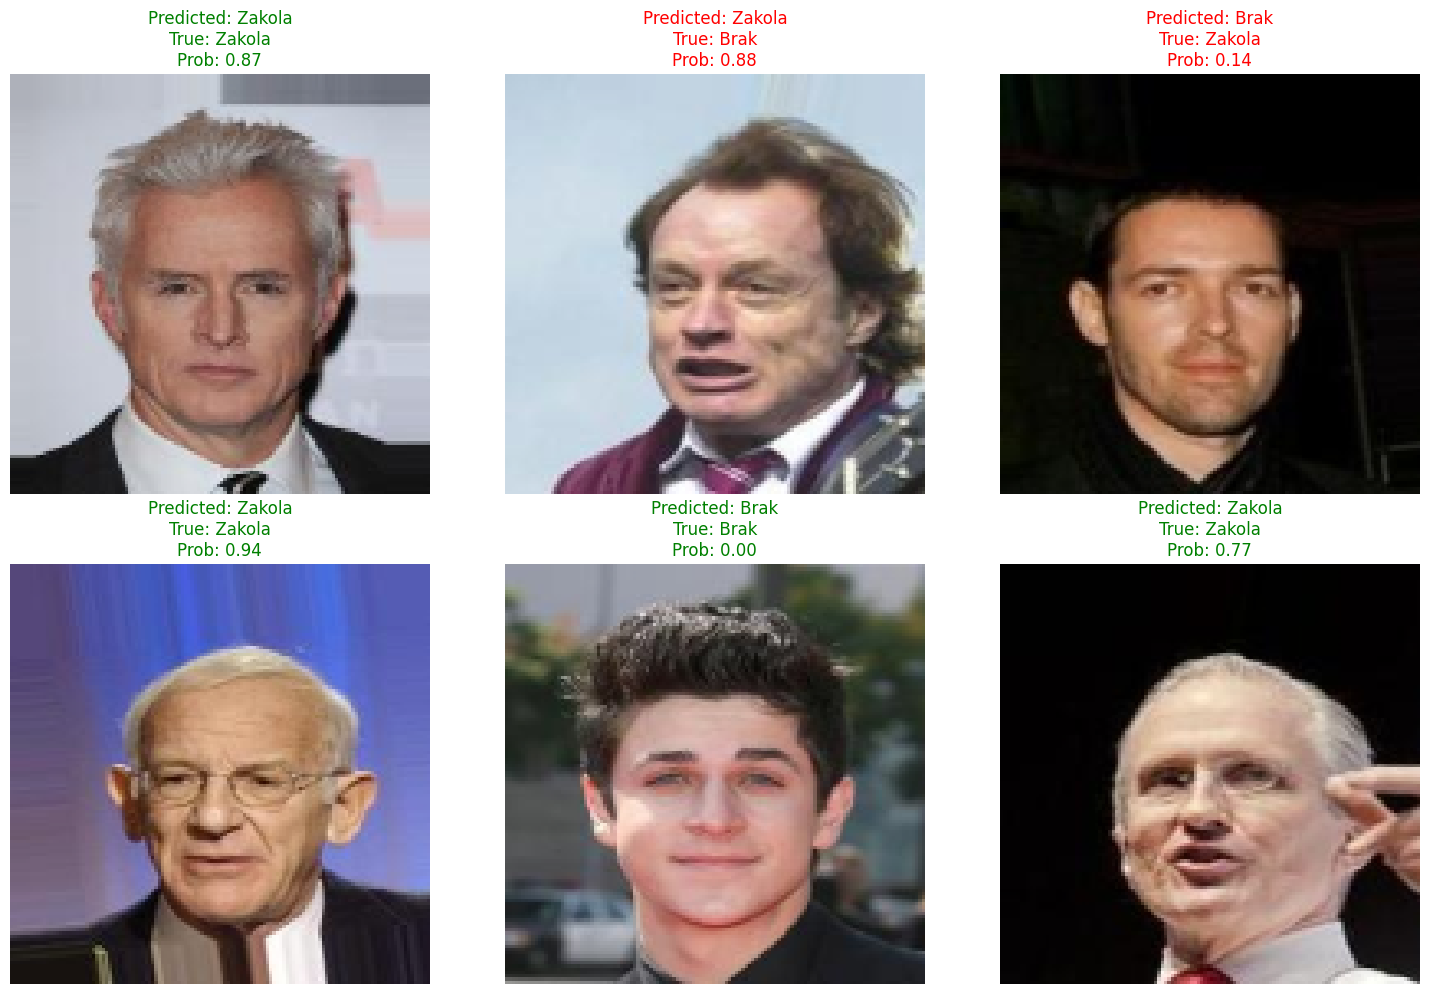

In [43]:
# Wybór losowych indeksów ze zbioru testowego
random_indices = random.sample(range(len(test_df)), 6)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(random_indices):
    # Pobranie danych o zdjęciu z DataFrame testowego
    img_filename = test_df.iloc[idx]['filename']
    true_label_code = int(test_df.iloc[idx]['label'])
    true_label_name = "Zakola" if true_label_code == 1 else "Brak"

    # Wczytanie i przygotowanie zdjęcia
    sample_img = os.path.join(img_folder_path, img_filename)
    img_bgr = cv2.imread(sample_img)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))

    # Przygotowanie do modelu (normalizacja i dodanie wymiaru batcha)
    img_array = img_resized / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predykcja modelu
    prediction_prob = model.predict(img_array, verbose=0)[0][0]
    pred_label_code = 1 if prediction_prob > 0.5 else 0
    pred_label_name = "Zakola" if pred_label_code == 1 else "Brak"

    # Wyświetlenie zdjęcia
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_resized)

    # Zielony kolor dla poprawnej odpowiedzi, czerwony dla błędu
    color = "green" if pred_label_code == true_label_code else "red"

    plt.title(f"Predicted: {pred_label_name}\nTrue: {true_label_name}\nProb: {prediction_prob:.2f}",
              color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Własne przykłady

Zaznacz plik ze swoim zdjęciem (jpg lub png):


Saving Z.PNG to Z.PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


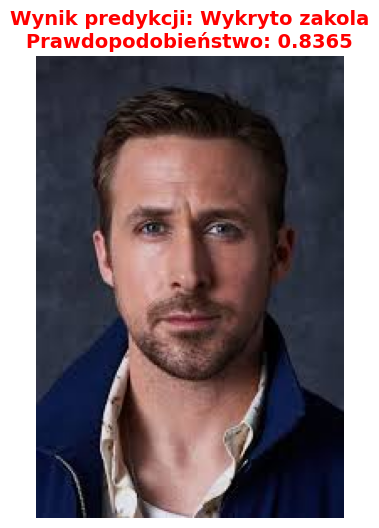

In [44]:
from google.colab import files

# Wgrywanie pliku
print("Zaznacz plik ze swoim zdjęciem (jpg lub png):")
uploaded = files.upload()

# Pobranie nazwy wgranego pliku
if uploaded:
    filename = list(uploaded.keys())[0]

    # Wczytanie i wstępna obróbka
    img_bgr = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Model był trenowany na zdjęciach 128x128
    img_resized = cv2.resize(img_rgb, (128, 128))

    # Normalizacja
    img_normalized = img_resized / 255.0

    # Dodanie wymiaru batcha
    img_final = np.expand_dims(img_normalized, axis=0)

    # Predykcja modelu
    prediction_prob = model.predict(img_final)[0][0]

    # Interpretacja wyniku (próg 0.5)
    if prediction_prob > 0.5:
        result = "Wykryto zakola"
        color = 'red'
    else:
        result = "Brak zakoli"
        color = 'green'

    # Wizualizacja wyniku
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Wynik predykcji: {result}\nPrawdopodobieństwo: {prediction_prob:.4f}",
              color=color, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

    # Usuń plik po analizie
    os.remove(filename)
else:
    print("Nie wgrano pliku.")